# ДЗ 2. DQN: Pong и Breakout


## Установка


In [ ]:
!pip install -q gymnasium torch matplotlib numpy pillow ale-py
!pip install -q "gymnasium[atari]"
!AutoROM --accept-license


AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


In [ ]:
# import subprocess, sys
# subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gymnasium", "torch", "matplotlib", "numpy", "pillow", "ale-py", "autorom"])
# subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gymnasium[atari]"])
# subprocess.check_call([sys.executable, "-m", "AutoROM", "--accept-license"])

## Визуализация


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output

def show_progress(rewards_batch, log, reward_range=None, loss_batch=None, log_loss=[]):
    if reward_range is None:
        reward_range = [-990, +10]
    mean_reward = np.mean(rewards_batch)
    log.append([mean_reward])
    if not (loss_batch is None):
      mean_loss = np.mean(loss_batch)
      log_loss.append([mean_loss])

    clear_output(True)
    plt.figure(figsize=[8, 4])
    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(list(zip(*log))[0], label='Mean rewards')
    ax1.legend(loc=4)
    ax1.grid()

    if not (loss_batch is None):
      ax2 = plt.subplot(1, 2, 2)
      ax2.plot(list(zip(*log_loss))[0], label='Mean loss')
      ax2.legend(loc=4)
      ax2.grid()

    plt.grid()
    plt.grid()
    plt.show()


## Функции: сеть, буфер, шаг оптимизации


In [ ]:
import gymnasium as gym
import ale_py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from collections import deque, namedtuple
import random
import math
from PIL import Image
import os
from datetime import datetime

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

REPLAY_WARMUP = 10000

Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward', 'done'))
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class DQN(nn.Module):
    def __init__(self, h, w, outputs):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(FRAME_STACK, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)

        self.fc1 = nn.Linear(3136, 512)
        self.fc2 = nn.Linear(512, outputs)

    def forward(self, x):
        x = x.float() / 255.0
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def preprocess_frame(frame):
    img = Image.fromarray(frame)
    img = img.convert('L').resize((84, 84))
    return np.array(img)

class FrameStack:
    def __init__(self, capacity):
        self.frames = deque([], maxlen=capacity)

    def push(self, frame):
        self.frames.append(frame)

    def get_stacked_frames(self):
        return np.stack(self.frames, axis=0)

    def reset(self, initial_frame):
        self.frames.clear()
        for _ in range(FRAME_STACK):
            self.push(initial_frame)

REW_LIST = []

def select_action(state, steps_done):
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)

    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[random.randrange(n_actions)]], device=device, dtype=torch.long)

def optimize_model():
    if len(memory) < max(BATCH_SIZE, REPLAY_WARMUP):
        return

    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)),
                                 device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])

    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = policy_net(state_batch).gather(1, action_batch)

    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0].detach()

    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    for param in policy_net.parameters():
        param.grad.data.clamp_(-1, 1)
    optimizer.step()

    return loss.item()


## Цикл обучения


In [ ]:
def train(writer):
    steps_done = 0

    for episode in range(NUM_EPISODES):
        frame, _ = env.reset()
        frame = preprocess_frame(frame)
        frame_stack = FrameStack(FRAME_STACK)
        frame_stack.reset(frame)
        state = torch.tensor(frame_stack.get_stacked_frames(), device=device).unsqueeze(0)

        total_reward = 0
        episode_loss = 0
        num_steps = 0

        while True:
            action = select_action(state, steps_done)
            next_frame, reward, terminated, truncated, _ = env.step(action.item())
            steps_done += 1
            done = terminated or truncated
            total_reward += reward
            clipped_reward = max(-1.0, min(1.0, reward))
            clipped_reward = torch.tensor([clipped_reward], device=device)

            next_frame = preprocess_frame(next_frame)
            frame_stack.push(next_frame)
            if not done:
                next_state = torch.tensor(frame_stack.get_stacked_frames(), device=device).unsqueeze(0)
            else:
                next_state = None

            memory.push(state, action, next_state, clipped_reward, torch.tensor([done], device=device))

            state = next_state

            loss = optimize_model()
            if loss is not None:
                episode_loss += loss

            num_steps += 1

            if steps_done % TARGET_UPDATE == 0:
                target_net.load_state_dict(policy_net.state_dict())

            if done:
                break

        avg_loss = episode_loss / num_steps if num_steps > 0 else 0
        writer.add_scalar('Episode Reward', total_reward, episode)
        writer.add_scalar('Episode Loss', avg_loss, episode)
        writer.add_scalar('Epsilon', EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY), episode)

        print(f'Episode {episode}, Total reward: {total_reward:.2f}, Steps: {num_steps}, Avg loss: {avg_loss:.4f}, Epsilon: {EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY):.4f}')
        REW_LIST.append(total_reward)

    torch.save(policy_net.state_dict(), 'assault_dqn.pth')
    writer.close()
    env.close()


## Pong


In [ ]:
NUM_EPISODES = 150
EPS_DECAY = max(50_000, int(100_000 * (NUM_EPISODES / 600)))

### Память 100000, lr 1e-4, batch 32


In [ ]:
FRAME_STACK = 4
BATCH_SIZE = 32
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.02
TARGET_UPDATE = 1000
MEMORY_CAPACITY = 100000
LR = 0.0001

env = gym.make("ALE/Pong-v5", render_mode="rgb_array")
n_actions = env.action_space.n

init_frame = preprocess_frame(env.reset()[0])
h, w = init_frame.shape
policy_net = DQN(h, w, n_actions).to(device)
target_net = DQN(h, w, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayMemory(MEMORY_CAPACITY)

REW_LIST.clear()
log_dir = f"runs/exp_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir)
train(writer)


Episode 0, Total reward: -21.00, Steps: 914, Avg loss: 0.0000, Epsilon: 0.9822
Episode 1, Total reward: -20.00, Steps: 932, Avg loss: 0.0000, Epsilon: 0.9645
Episode 2, Total reward: -21.00, Steps: 764, Avg loss: 0.0000, Epsilon: 0.9502
Episode 3, Total reward: -21.00, Steps: 880, Avg loss: 0.0000, Epsilon: 0.9339
Episode 4, Total reward: -20.00, Steps: 871, Avg loss: 0.0000, Epsilon: 0.9181
Episode 5, Total reward: -17.00, Steps: 1420, Avg loss: 0.0000, Epsilon: 0.8930
Episode 6, Total reward: -19.00, Steps: 1101, Avg loss: 0.0000, Epsilon: 0.8740
Episode 7, Total reward: -19.00, Steps: 999, Avg loss: 0.0000, Epsilon: 0.8571
Episode 8, Total reward: -20.00, Steps: 901, Avg loss: 0.0000, Epsilon: 0.8421
Episode 9, Total reward: -21.00, Steps: 820, Avg loss: 0.0000, Epsilon: 0.8288
Episode 10, Total reward: -21.00, Steps: 884, Avg loss: 0.0064, Epsilon: 0.8146
Episode 11, Total reward: -21.00, Steps: 783, Avg loss: 0.0119, Epsilon: 0.8022
Episode 12, Total reward: -20.00, Steps: 981, Av

In [ ]:
pong_m100k_lr1e4 = list(REW_LIST)


### Память 50000, lr 1e-4, batch 32


In [ ]:
FRAME_STACK = 4
BATCH_SIZE = 32
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.02
TARGET_UPDATE = 1000
MEMORY_CAPACITY = 50000
LR = 0.0001

env = gym.make("ALE/Pong-v5", render_mode="rgb_array")
n_actions = env.action_space.n

init_frame = preprocess_frame(env.reset()[0])
h, w = init_frame.shape
policy_net = DQN(h, w, n_actions).to(device)
target_net = DQN(h, w, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayMemory(MEMORY_CAPACITY)

REW_LIST.clear()
log_dir = f"runs/exp_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir)
train(writer)


Episode 0, Total reward: -21.00, Steps: 942, Avg loss: 0.0000, Epsilon: 0.9817
Episode 1, Total reward: -21.00, Steps: 858, Avg loss: 0.0000, Epsilon: 0.9653
Episode 2, Total reward: -20.00, Steps: 950, Avg loss: 0.0000, Epsilon: 0.9476
Episode 3, Total reward: -19.00, Steps: 1015, Avg loss: 0.0000, Epsilon: 0.9289
Episode 4, Total reward: -19.00, Steps: 1018, Avg loss: 0.0000, Epsilon: 0.9106
Episode 5, Total reward: -20.00, Steps: 842, Avg loss: 0.0000, Epsilon: 0.8957
Episode 6, Total reward: -21.00, Steps: 824, Avg loss: 0.0000, Epsilon: 0.8814
Episode 7, Total reward: -21.00, Steps: 944, Avg loss: 0.0000, Epsilon: 0.8653
Episode 8, Total reward: -21.00, Steps: 1031, Avg loss: 0.0000, Epsilon: 0.8480
Episode 9, Total reward: -21.00, Steps: 888, Avg loss: 0.0000, Epsilon: 0.8335
Episode 10, Total reward: -21.00, Steps: 824, Avg loss: 0.0017, Epsilon: 0.8202
Episode 11, Total reward: -21.00, Steps: 824, Avg loss: 0.0121, Epsilon: 0.8071
Episode 12, Total reward: -21.00, Steps: 824, A

In [ ]:
pong_m50k_lr1e4 = list(REW_LIST)


### Память 100000, lr 1e-4, batch 128


In [ ]:
FRAME_STACK = 4
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.02
TARGET_UPDATE = 1000
MEMORY_CAPACITY = 100000
LR = 0.0001

env = gym.make("ALE/Pong-v5", render_mode="rgb_array")
n_actions = env.action_space.n

init_frame = preprocess_frame(env.reset()[0])
h, w = init_frame.shape
policy_net = DQN(h, w, n_actions).to(device)
target_net = DQN(h, w, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayMemory(MEMORY_CAPACITY)

REW_LIST.clear()
log_dir = f"runs/exp_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir)
train(writer)


Episode 0, Total reward: -18.00, Steps: 1101, Avg loss: 0.0000, Epsilon: 0.9787
Episode 1, Total reward: -21.00, Steps: 764, Avg loss: 0.0000, Epsilon: 0.9641
Episode 2, Total reward: -21.00, Steps: 824, Avg loss: 0.0000, Epsilon: 0.9487
Episode 3, Total reward: -21.00, Steps: 853, Avg loss: 0.0000, Epsilon: 0.9330
Episode 4, Total reward: -21.00, Steps: 992, Avg loss: 0.0000, Epsilon: 0.9150
Episode 5, Total reward: -21.00, Steps: 945, Avg loss: 0.0000, Epsilon: 0.8983
Episode 6, Total reward: -20.00, Steps: 900, Avg loss: 0.0000, Epsilon: 0.8826
Episode 7, Total reward: -21.00, Steps: 885, Avg loss: 0.0000, Epsilon: 0.8675
Episode 8, Total reward: -20.00, Steps: 1048, Avg loss: 0.0000, Epsilon: 0.8499
Episode 9, Total reward: -21.00, Steps: 931, Avg loss: 0.0000, Epsilon: 0.8346
Episode 10, Total reward: -21.00, Steps: 1090, Avg loss: 0.0035, Epsilon: 0.8170
Episode 11, Total reward: -20.00, Steps: 872, Avg loss: 0.0115, Epsilon: 0.8033
Episode 12, Total reward: -21.00, Steps: 882, A

In [ ]:
pong_m100k_b128 = list(REW_LIST)


## Breakout


### Память 100000, lr 1e-4, TARGET_UPDATE 500


In [ ]:
FRAME_STACK = 4
BATCH_SIZE = 32
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.02
TARGET_UPDATE = 500
MEMORY_CAPACITY = 100000
LR = 0.0001

env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
n_actions = env.action_space.n

init_frame = preprocess_frame(env.reset()[0])
h, w = init_frame.shape
policy_net = DQN(h, w, n_actions).to(device)
target_net = DQN(h, w, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayMemory(MEMORY_CAPACITY)

REW_LIST.clear()
log_dir = f"runs/exp_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir)
train(writer)


Episode 0, Total reward: 1.00, Steps: 180, Avg loss: 0.0000, Epsilon: 0.9965
Episode 1, Total reward: 2.00, Steps: 207, Avg loss: 0.0000, Epsilon: 0.9924
Episode 2, Total reward: 1.00, Steps: 178, Avg loss: 0.0000, Epsilon: 0.9890
Episode 3, Total reward: 4.00, Steps: 283, Avg loss: 0.0000, Epsilon: 0.9835
Episode 4, Total reward: 0.00, Steps: 135, Avg loss: 0.0000, Epsilon: 0.9809
Episode 5, Total reward: 0.00, Steps: 127, Avg loss: 0.0000, Epsilon: 0.9785
Episode 6, Total reward: 3.00, Steps: 243, Avg loss: 0.0000, Epsilon: 0.9738
Episode 7, Total reward: 0.00, Steps: 132, Avg loss: 0.0000, Epsilon: 0.9713
Episode 8, Total reward: 0.00, Steps: 134, Avg loss: 0.0000, Epsilon: 0.9688
Episode 9, Total reward: 1.00, Steps: 180, Avg loss: 0.0000, Epsilon: 0.9654
Episode 10, Total reward: 2.00, Steps: 187, Avg loss: 0.0000, Epsilon: 0.9618
Episode 11, Total reward: 0.00, Steps: 140, Avg loss: 0.0000, Epsilon: 0.9592
Episode 12, Total reward: 1.00, Steps: 159, Avg loss: 0.0000, Epsilon: 0.9

In [ ]:
break_t500 = list(REW_LIST)


### Память 100000, lr 1e-4, TARGET_UPDATE 2000


In [ ]:
FRAME_STACK = 4
BATCH_SIZE = 32
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.02
TARGET_UPDATE = 2000
MEMORY_CAPACITY = 100000
LR = 0.0001

env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
n_actions = env.action_space.n

init_frame = preprocess_frame(env.reset()[0])
h, w = init_frame.shape
policy_net = DQN(h, w, n_actions).to(device)
target_net = DQN(h, w, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayMemory(MEMORY_CAPACITY)

REW_LIST.clear()
log_dir = f"runs/exp_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir)
train(writer)


Episode 0, Total reward: 2.00, Steps: 203, Avg loss: 0.0000, Epsilon: 0.9960
Episode 1, Total reward: 1.00, Steps: 194, Avg loss: 0.0000, Epsilon: 0.9922
Episode 2, Total reward: 2.00, Steps: 231, Avg loss: 0.0000, Epsilon: 0.9878
Episode 3, Total reward: 0.00, Steps: 134, Avg loss: 0.0000, Epsilon: 0.9852
Episode 4, Total reward: 1.00, Steps: 173, Avg loss: 0.0000, Epsilon: 0.9818
Episode 5, Total reward: 0.00, Steps: 130, Avg loss: 0.0000, Epsilon: 0.9793
Episode 6, Total reward: 2.00, Steps: 229, Avg loss: 0.0000, Epsilon: 0.9750
Episode 7, Total reward: 0.00, Steps: 134, Avg loss: 0.0000, Epsilon: 0.9724
Episode 8, Total reward: 0.00, Steps: 123, Avg loss: 0.0000, Epsilon: 0.9701
Episode 9, Total reward: 1.00, Steps: 173, Avg loss: 0.0000, Epsilon: 0.9668
Episode 10, Total reward: 0.00, Steps: 147, Avg loss: 0.0000, Epsilon: 0.9640
Episode 11, Total reward: 4.00, Steps: 279, Avg loss: 0.0000, Epsilon: 0.9588
Episode 12, Total reward: 2.00, Steps: 189, Avg loss: 0.0000, Epsilon: 0.9

In [ ]:
break_t2000 = list(REW_LIST)


## Графики


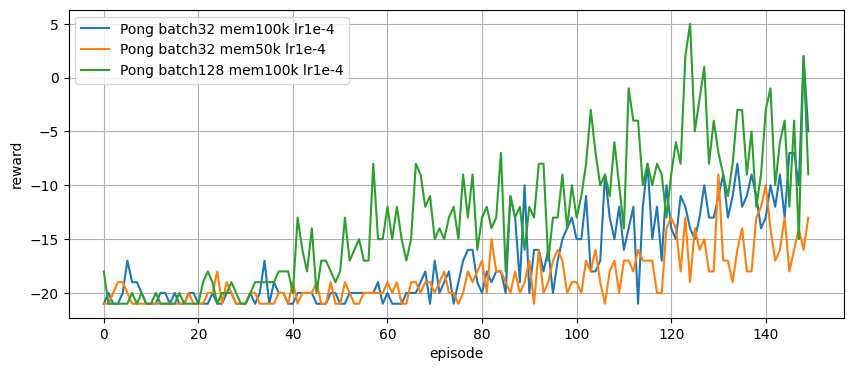

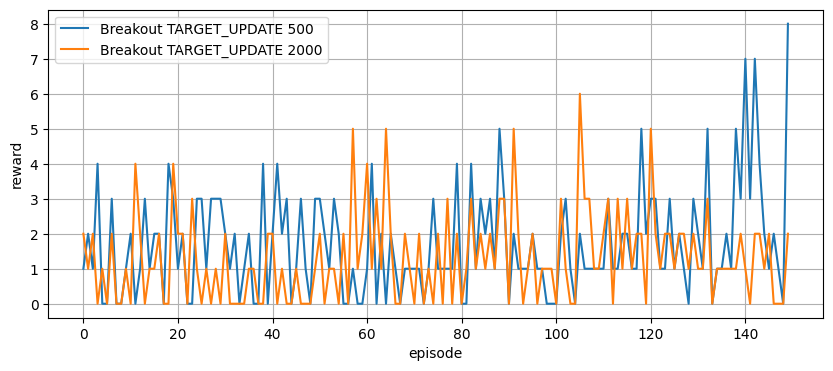

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(pong_m100k_lr1e4, label='Pong batch32 mem100k lr1e-4')
plt.plot(pong_m50k_lr1e4, label='Pong batch32 mem50k lr1e-4')
plt.plot(pong_m100k_b128, label='Pong batch128 mem100k lr1e-4')
plt.xlabel('episode')
plt.ylabel('reward')
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 4))
plt.plot(break_t500, label='Breakout TARGET_UPDATE 500')
plt.plot(break_t2000, label='Breakout TARGET_UPDATE 2000')
plt.xlabel('episode')
plt.ylabel('reward')
plt.legend()
plt.grid(True)
plt.show()


## Выводы

- Обучение проводилось на 150 эпизодах с архитектурой DQN из статьи DeepMind 2015 (3 свёрточных слоя, replay buffer, target network, frame skip). Сравнивались гиперпараметры: размер буфера, размер батча (Pong) и частота обновления target-сети (Breakout).

- Pong - размер replay buffer (100k vs 50k, batch 32):
Буфер 100k: средний reward за последние 10 эпизодов = -8.4, лучший = +2. Буфер 50k: средний = -14.7, лучший = -9. Большой буфер хранит более разнообразные переходы, поэтому мини-батчи менее коррелированы друг с другом. Маленький буфер быстро затирает старый опыт - агент фактически учится только на недавних траекториях, что увеличивает дисперсию обновлений и замедляет сходимость.

- Pong - размер батча (32 vs 128, mem 100k):
Batch 128: средний reward = -6.2, лучший = +5. Batch 32: средний = -8.4, лучший = +2. Больший батч лучше аппроксимирует математическое ожидание градиента - каждый шаг оптимизации даёт более точное направление обновления. Это особенно важно при ограниченном бюджете эпизодов, когда на счету каждый шаг. При этом время обучения не увеличивается - растёт только потребление памяти GPU.

- Breakout - частота обновления target-сети (500 vs 2000 шагов):
TARGET_UPDATE=500: средний reward = 3.5, лучший = 8. TARGET_UPDATE=2000: средний = 1.0, лучший = 6. При бюджете ~30k шагов (150 эпизодов) target-сеть обновляется ~60 раз vs ~15 раз. Более частое обновление позволяет target-значениям точнее отражать текущую политику, и bootstrap-оценки Q оказываются более актуальными. Слишком редкое обновление приводит к тому, что агент оптимизирует устаревшие target-значения.

- Итог: при ограниченном бюджете обучения (150 эпизодов) наибольшее влияние оказывают размер буфера (100k >> 50k), размер батча (128 > 32) и частота обновления target-сети (500 > 2000 шагов). Все три параметра влияют на качество и актуальность градиентных обновлений, не увеличивая время обучения.
